<a href="https://colab.research.google.com/github/danishasifahmed/p1-ml-pipeline/blob/main/feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mlflow -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import pickle
import warnings
warnings.filterwarnings("ignore")  # suppress minor sklearn warnings

%matplotlib inline
sns.set_theme(style="whitegrid")
print("All imports successful ✓")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

In [2]:
# Load raw data
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# --- Repeat Day 2 cleaning so this notebook works standalone ---

# Step 1: Remove outliers using IQR
def remove_outliers_iqr(dataframe, columns, multiplier=3.0):
    df_clean = dataframe.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

cols_to_clean = ["AveRooms", "AveBedrms", "Population", "AveOccup"]
df_clean = remove_outliers_iqr(df, cols_to_clean)

# Step 2: Remove capped target values
df_clean = df_clean[df_clean["MedHouseVal"] < 5.0].copy()

print(f"Clean dataset shape: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")
display(df_clean.head())

Clean dataset shape: (18440, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
def engineer_features(dataframe):
    """
    Create new meaningful features from the existing California Housing columns.
    Returns a new dataframe with original + new features.
    """
    df_eng = dataframe.copy()  # never modify the original

    # --- Feature 1: Rooms per bedroom ---
    # A house with 8 rooms but only 2 bedrooms has lots of living space
    # This ratio captures "spaciousness" better than raw room count alone
    # Add small epsilon (0.001) to avoid division by zero if AveBedrms is ever 0
    df_eng["RoomsPerBedroom"] = df_eng["AveRooms"] / (df_eng["AveBedrms"] + 0.001)

    # --- Feature 2: Population density (people per room) ---
    # Crowded areas tend to have lower house values
    # This captures how densely packed a block group is
    df_eng["PopulationPerRoom"] = df_eng["Population"] / (df_eng["AveRooms"] + 0.001)

    # --- Feature 3: Income per occupant ---
    # Wealthy households with fewer people = expensive area
    # MedInc is household income; AveOccup is people per household
    df_eng["IncomePerOccupant"] = df_eng["MedInc"] / (df_eng["AveOccup"] + 0.001)

    # --- Feature 4: Is near coast ---
    # California coastal areas (west side) are significantly more expensive
    # Longitude < -119 roughly corresponds to the coastal strip
    # This binary flag (0 or 1) lets the model treat coastal areas differently
    df_eng["IsNearCoast"] = (df_eng["Longitude"] < -119).astype(int)

    # --- Feature 5: Is in major metro area ---
    # SF Bay Area and LA basin have very different pricing patterns
    # We define metro as latitude between 33.5 and 38.5 (covers LA to SF)
    df_eng["IsMajorMetro"] = (
        (df_eng["Latitude"] >= 33.5) & (df_eng["Latitude"] <= 38.5)
    ).astype(int)

    # --- Feature 6: Income x HouseAge interaction ---
    # In expensive areas, newer houses command a much bigger premium
    # An interaction term captures this combined effect
    # Without this, the model treats income and age as fully independent
    df_eng["IncomeAgeInteraction"] = df_eng["MedInc"] * df_eng["HouseAge"]

    return df_eng

# Apply feature engineering
df_engineered = engineer_features(df_clean)

print(f"Shape before: {df_clean.shape}")
print(f"Shape after:  {df_engineered.shape}")
print(f"\nNew features added:")
new_cols = [c for c in df_engineered.columns if c not in df_clean.columns]
for col in new_cols:
    print(f"  + {col}: min={df_engineered[col].min():.2f}, max={df_engineered[col].max():.2f}, mean={df_engineered[col].mean():.2f}")

Shape before: (18440, 9)
Shape after:  (18440, 15)

New features added:
  + RoomsPerBedroom: min=1.00, max=8.86, mean=4.93
  + PopulationPerRoom: min=0.83, max=2248.95, mean=279.16
  + IncomePerOccupant: min=0.13, max=7.46, mean=1.33
  + IsNearCoast: min=0.00, max=1.00, mean=0.47
  + IsMajorMetro: min=0.00, max=1.00, mean=0.82
  + IncomeAgeInteraction: min=1.62, max=780.01, mean=103.02


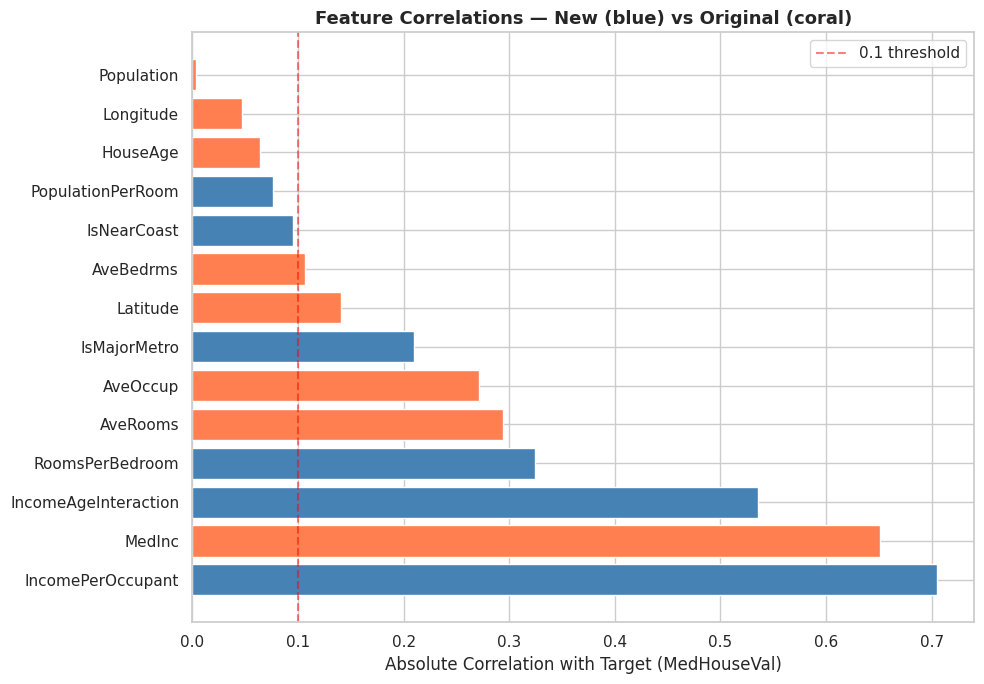


=== Correlation Values ===
IncomePerOccupant       0.705
MedInc                  0.651
IncomeAgeInteraction    0.535
RoomsPerBedroom         0.324
AveRooms                0.294
AveOccup                0.272
IsMajorMetro            0.210
Latitude                0.141
AveBedrms               0.106
IsNearCoast             0.095
PopulationPerRoom       0.077
HouseAge                0.064
Longitude               0.047
Population              0.003

New features that beat the 0.1 threshold:
  RoomsPerBedroom               : 0.324  ✓ useful
  PopulationPerRoom             : 0.077  ✗ weak
  IncomePerOccupant             : 0.705  ✓ useful
  IsNearCoast                   : 0.095  ✗ weak
  IsMajorMetro                  : 0.210  ✓ useful
  IncomeAgeInteraction          : 0.535  ✓ useful


In [4]:
# Check how well our new features correlate with the target
all_features = [c for c in df_engineered.columns if c != "MedHouseVal"]
correlations = df_engineered[all_features + ["MedHouseVal"]].corr()["MedHouseVal"].drop("MedHouseVal")

# Sort and display — we want to see if our new features rank high
correlations_sorted = correlations.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors = ["steelblue" if col in new_cols else "coral" for col in correlations_sorted.index]
plt.barh(correlations_sorted.index, correlations_sorted.values, color=colors)
plt.xlabel("Absolute Correlation with Target (MedHouseVal)")
plt.title("Feature Correlations — New (blue) vs Original (coral)", fontsize=13, fontweight="bold")
plt.axvline(x=0.1, color="red", linestyle="--", alpha=0.5, label="0.1 threshold")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== Correlation Values ===")
print(correlations_sorted.round(3).to_string())
print(f"\nNew features that beat the 0.1 threshold:")
for col in new_cols:
    val = abs(correlations[col])
    status = "✓ useful" if val > 0.1 else "✗ weak"
    print(f"  {col:30s}: {val:.3f}  {status}")

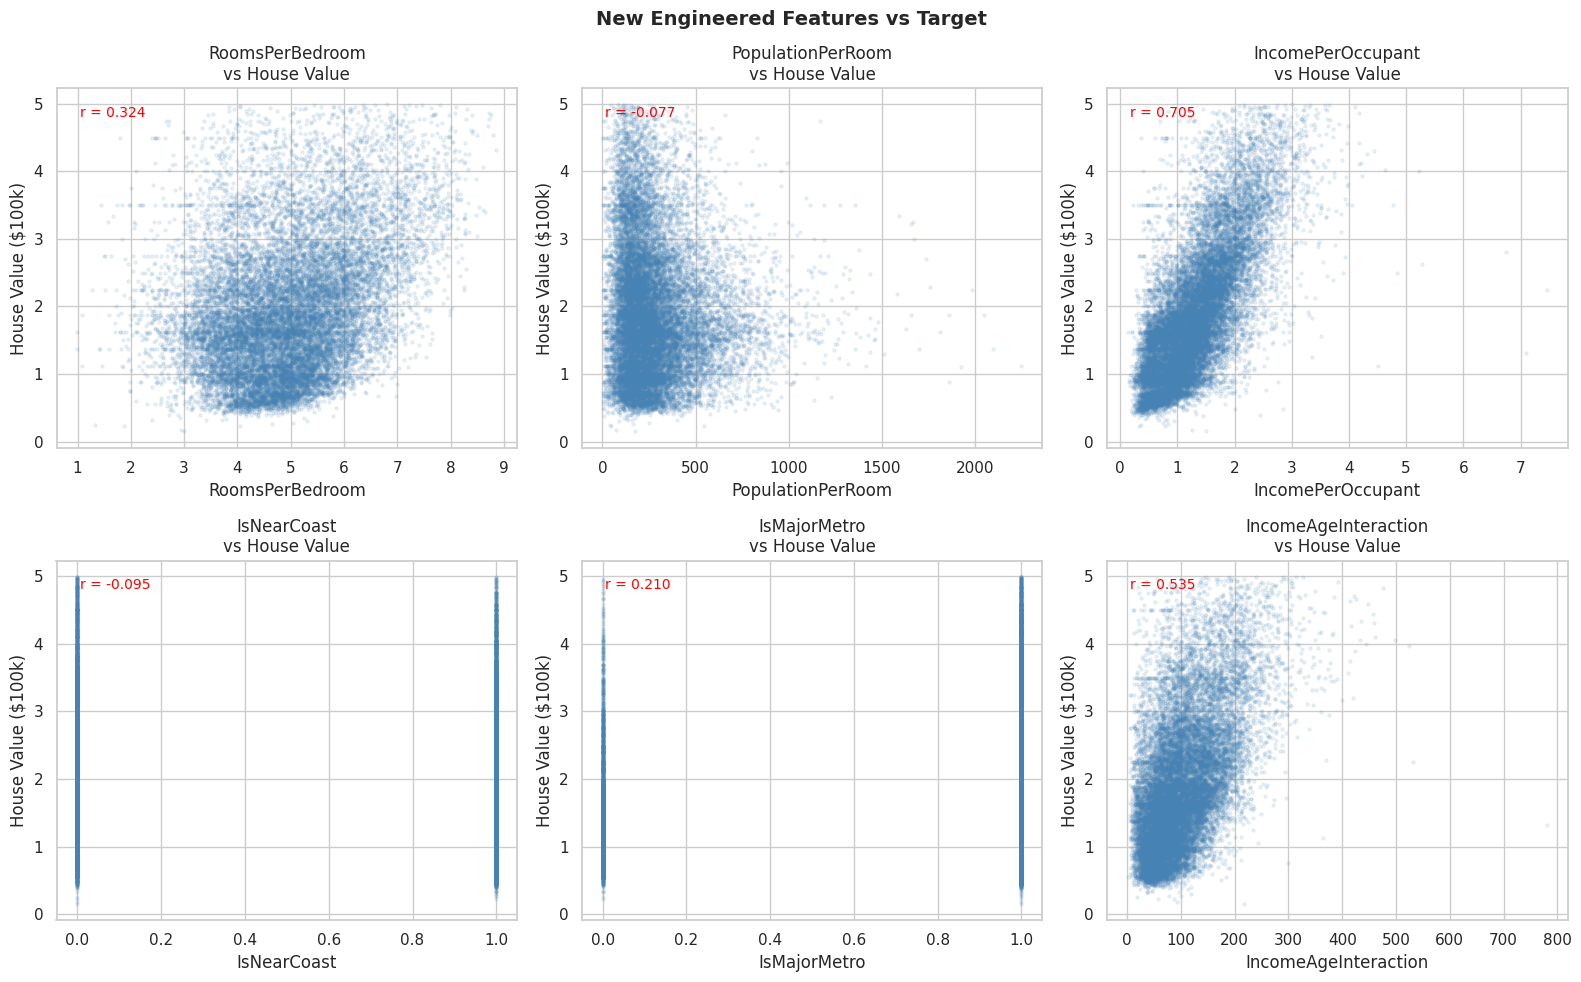

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(new_cols):
    # Scatter plot with transparency — shows density of data points
    axes[i].scatter(
        df_engineered[col],
        df_engineered["MedHouseVal"],
        alpha=0.1,          # low alpha because 18,000+ points would be a solid blob
        color="steelblue",
        s=5                 # small dot size for same reason
    )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("House Value ($100k)")
    axes[i].set_title(f"{col}\nvs House Value")

    # Add correlation value to the plot
    corr_val = df_engineered[col].corr(df_engineered["MedHouseVal"])
    axes[i].text(
        0.05, 0.92,
        f"r = {corr_val:.3f}",
        transform=axes[i].transAxes,  # position relative to plot (0-1 scale)
        fontsize=10,
        color="red"
    )

plt.suptitle("New Engineered Features vs Target", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [6]:
# Separate features from target
X = df_engineered.drop(columns=["MedHouseVal"])
y = df_engineered["MedHouseVal"]

# --- Define which columns get which treatment ---

# Binary features (0 or 1) — do NOT scale these
# Scaling a binary column would give values like -0.3 or 1.7 which is meaningless
binary_features = ["IsNearCoast", "IsMajorMetro"]

# All other numeric features — these WILL be scaled
numeric_features = [col for col in X.columns if col not in binary_features]

print(f"Numeric features to scale ({len(numeric_features)}):")
for col in numeric_features:
    print(f"  - {col}")

print(f"\nBinary features to leave as-is ({len(binary_features)}):")
for col in binary_features:
    print(f"  - {col}")


Numeric features to scale (12):
  - MedInc
  - HouseAge
  - AveRooms
  - AveBedrms
  - Population
  - AveOccup
  - Latitude
  - Longitude
  - RoomsPerBedroom
  - PopulationPerRoom
  - IncomePerOccupant
  - IncomeAgeInteraction

Binary features to leave as-is (2):
  - IsNearCoast
  - IsMajorMetro


In [7]:
# ColumnTransformer applies different transformations to different column groups
# 'remainder=passthrough' means any columns not mentioned are passed through unchanged
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",              # name for this transformer (any string)
            StandardScaler(),   # what to apply
            numeric_features    # which columns to apply it to
        ),
        (
            "bin",              # name for the binary transformer
            "passthrough",      # "passthrough" = do nothing, keep as-is
            binary_features     # which columns to leave alone
        )
    ]
)

# Pipeline chains steps in order: first preprocess, then (later) a model fits
# For now we just have the preprocessing step — we'll add the model in Day 4
preprocessing_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor)   # step name + step object
])

print("Pipeline created ✓")
print("\nPipeline steps:")
for name, step in preprocessing_pipeline.steps:
    print(f"  → {name}: {step}")

Pipeline created ✓

Pipeline steps:
  → preprocessor: ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                                  'Population', 'AveOccup', 'Latitude',
                                  'Longitude', 'RoomsPerBedroom',
                                  'PopulationPerRoom', 'IncomePerOccupant',
                                  'IncomeAgeInteraction']),
                                ('bin', 'passthrough',
                                 ['IsNearCoast', 'IsMajorMetro'])])


In [8]:
# Split BEFORE fitting the pipeline — same rule as Day 2
# Fit on training data only, transform both
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

# fit_transform on train: learns the scaling parameters AND applies them
X_train_processed = preprocessing_pipeline.fit_transform(X_train)

# transform only on test: uses the learned parameters from training
X_test_processed = preprocessing_pipeline.transform(X_test)

# Get the final column names after transformation
# ColumnTransformer reorders columns: numeric first, then binary
final_columns = numeric_features + binary_features

# Convert back to DataFrames with column names
X_train_final = pd.DataFrame(X_train_processed, columns=final_columns)
X_test_final  = pd.DataFrame(X_test_processed,  columns=final_columns)

print(f"\nFinal processed shape — Train: {X_train_final.shape}, Test: {X_test_final.shape}")
print(f"\nFinal columns ({len(final_columns)}):")
print(final_columns)


Training set: (14752, 14)
Test set:     (3688, 14)

Final processed shape — Train: (14752, 14), Test: (3688, 14)

Final columns (14):
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'RoomsPerBedroom', 'PopulationPerRoom', 'IncomePerOccupant', 'IncomeAgeInteraction', 'IsNearCoast', 'IsMajorMetro']


In [9]:
# Sanity check: binary columns should still only contain 0 and 1
print("=== Binary feature check (should only be 0 and 1) ===")
for col in binary_features:
    unique_vals = sorted(X_train_final[col].unique())
    print(f"  {col}: unique values = {unique_vals}")

# Sanity check: numeric columns should be centered around 0
print("\n=== Numeric feature check (mean ≈ 0, std ≈ 1) ===")
for col in numeric_features[:4]:  # check first 4 as sample
    mean = X_train_final[col].mean()
    std  = X_train_final[col].std()
    print(f"  {col:30s}: mean={mean:.4f}, std={std:.4f}")


=== Binary feature check (should only be 0 and 1) ===
  IsNearCoast: unique values = [np.float64(0.0), np.float64(1.0)]
  IsMajorMetro: unique values = [np.float64(0.0), np.float64(1.0)]

=== Numeric feature check (mean ≈ 0, std ≈ 1) ===
  MedInc                        : mean=-0.0000, std=1.0000
  HouseAge                      : mean=0.0000, std=1.0000
  AveRooms                      : mean=-0.0000, std=1.0000
  AveBedrms                     : mean=-0.0000, std=1.0000


In [10]:
# Save processed train/test sets for Day 4 (model training)
X_train_final.to_csv("X_train_engineered.csv", index=False)
X_test_final.to_csv("X_test_engineered.csv",   index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv",   index=False)

# Save the fitted pipeline — this is critical for Day 6 (prediction)
# In production, this pipeline is what you deploy, not just the model
with open("preprocessing_pipeline.pkl", "wb") as f:
    pickle.dump(preprocessing_pipeline, f)

# Save the list of final column names — needed when loading data in Day 4
with open("feature_names.pkl", "wb") as f:
    pickle.dump(final_columns, f)

print("✓ Saved: X_train_engineered.csv, X_test_engineered.csv")
print("✓ Saved: y_train.csv, y_test.csv")
print("✓ Saved: preprocessing_pipeline.pkl")
print("✓ Saved: feature_names.pkl")


✓ Saved: X_train_engineered.csv, X_test_engineered.csv
✓ Saved: y_train.csv, y_test.csv
✓ Saved: preprocessing_pipeline.pkl
✓ Saved: feature_names.pkl


In [11]:
print("=" * 55)
print("FEATURE ENGINEERING SUMMARY — Ready for Day 4")
print("=" * 55)
print(f"""
ORIGINAL FEATURES: 8
NEW FEATURES ADDED: 6
  + RoomsPerBedroom      — spaciousness ratio
  + PopulationPerRoom    — crowding measure
  + IncomePerOccupant    — wealth per person
  + IsNearCoast          — coastal location flag
  + IsMajorMetro         — metro area flag
  + IncomeAgeInteraction — combined income × age effect

TOTAL FEATURES FOR TRAINING: {len(final_columns)}

PIPELINE BUILT:
  → ColumnTransformer: scales numeric, passes binary as-is
  → Saved as preprocessing_pipeline.pkl for reuse

TRAIN/TEST SPLIT:
  → Training: {X_train_final.shape[0]:,} rows
  → Test:     {X_test_final.shape[0]:,} rows
  → random_state=42 (reproducible)

READY FOR DAY 4:
  → Train LinearRegression, Ridge, RandomForest
  → Log all experiments to MLflow
  → View results in MLflow UI
""")


FEATURE ENGINEERING SUMMARY — Ready for Day 4

ORIGINAL FEATURES: 8
NEW FEATURES ADDED: 6
  + RoomsPerBedroom      — spaciousness ratio
  + PopulationPerRoom    — crowding measure
  + IncomePerOccupant    — wealth per person
  + IsNearCoast          — coastal location flag
  + IsMajorMetro         — metro area flag
  + IncomeAgeInteraction — combined income × age effect

TOTAL FEATURES FOR TRAINING: 14

PIPELINE BUILT:
  → ColumnTransformer: scales numeric, passes binary as-is
  → Saved as preprocessing_pipeline.pkl for reuse

TRAIN/TEST SPLIT:
  → Training: 14,752 rows
  → Test:     3,688 rows
  → random_state=42 (reproducible)

READY FOR DAY 4:
  → Train LinearRegression, Ridge, RandomForest
  → Log all experiments to MLflow
  → View results in MLflow UI

